## Assignment 1: Markowitz Portfolio Optimization

This notebook constitutes the empirical component of Assignment 1. It constructs a **10-stock portfolio across 3 sectors**, evaluates **three annual risk budgets** (`20%`, `28%`, `40%`), and compares **convex optimization** with **Monte Carlo simulation**. The written report is provided in `README.md`, while this notebook contains the calculations, plots, and supporting tables.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import yfinance as yf
import cvxpy as cp

np.random.seed(42)

### Portfolio Universe, Data Source, and Assumptions


#### Portfolio Universe
The portfolio uses **10 U.S. large-cap stocks** across **three sectors**.

- **Technology:** AAPL, MSFT, NVDA, ORCL
- **Finance:** JPM, V, BAC
- **Health Care:** JNJ, PFE, UNH

#### Data Source and Date Range
- **Source:** Yahoo Finance via `yfinance`
- **Price field:** adjusted close prices obtained with `auto_adjust=True`
- **Download window requested:** `2020-01-01` to `2025-12-03`
- **Saved output window:** `2020-01-02` to `2025-12-02`

#### Model Assumptions
- **Long-only:** `w >= 0`
- **Fully invested:** `sum(w) = 1`
- **No transaction costs or shorting**
- **Annualization:** 252 trading days for both expected return and covariance


In [2]:
tickers = [
    'AAPL', 'MSFT', 'NVDA', 'ORCL',
    'JPM', 'V', 'BAC',
    'JNJ', 'PFE', 'UNH'
]

df = yf.download(tickers, start='2020-01-01', end='2025-12-03', group_by='ticker', auto_adjust=True, threads=True)

df.head()

[                       0%                       ]

[**********            20%                       ]  2 of 10 completed

[**************        30%                       ]  3 of 10 completed

[*******************   40%                       ]  4 of 10 completed

[**********************50%                       ]  5 of 10 completed

...

[**********************70%*********              ]  7 of 10 completed

[**********************80%*************          ]  8 of 10 completed

[**********************90%******************     ]  9 of 10 completed

[*********************100%***********************]  10 of 10 completed

Ticker             JPM                                                \
Price             Open        High         Low       Close    Volume   
Date                                                                   
2020-01-02  117.339119  118.438738  116.894240  118.430336  10803700   
2020-01-03  116.157869  117.619343  115.803061  116.867485  10386800   
2020-01-06  115.363755  116.808342  115.313070  116.774544  10259000   
2020-01-07  115.972023  116.461999  114.738645  114.789330  10531300   
2020-01-08  114.637262  116.225461  114.552791  115.684799   9695300   

Ticker               V                                                ...  \
Price             Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2020-01-02  180.407463  182.450171  180.140193  182.431076   8733000  ...   
2020-01-03  179.844232  182.278303  179.376504  180.980133   4899700  ...   
2020-01-06  179.452935  180.607931  178.651128  180.588837  10109500  ...   
2020-01-07  180.970634  181.457457  180.025652  180.111557   4392300  ...   
2020-01-08  180.875200  183.748351  180.216567  183.194717   5712000  ...   

Ticker           AAPL                                                    PFE  \
Price            Open       High        Low      Close     Volume       Open   
Date                                                                           
2020-01-02  71.344054  72.394086  71.091184  72.333878  135480400  27.158938   
2020-01-03  71.563236  72.389288  71.406697  71.630669  146322800  26.758118   
2020-01-06  70.754014  72.239942  70.503546  72.201408  118387200  26.827224   
2020-01-07  72.211033  72.466315  71.642674  71.861832  108872000  27.034536   
2020-01-08  71.565614  73.318870  71.565614  73.017830  132079200  26.785754   

Ticker                                                 
Price            High        Low      Close    Volume  
Date                                                   
2020-01-02  27.193489  26.868689  27.048365  16514072  
2020-01-03  27.117472  26.723563  26.903242  14922848  
2020-01-06  26.951618  26.744298  26.868689  15771951  
2020-01-07  27.041446  26.730466  26.778841  20108107  
2020-01-08  27.103645  26.778844  26.993074  16403507  

[5 rows x 50 columns]

In [3]:
adj_close = df.xs('Close', level=1, axis=1)
print(adj_close.head(),"\n\n")
print(adj_close.info())

Ticker             JPM           V       ORCL         JNJ         UNH  \
Date                                                                    
2020-01-02  118.430336  182.431076  49.149586  122.638214  263.196869   
2020-01-03  116.867485  180.980133  48.976475  121.218330  260.533386   
2020-01-06  116.774544  180.588837  49.231564  121.067131  262.342072   
2020-01-07  114.789330  180.111557  49.340897  121.806473  260.758423   
2020-01-08  115.684799  183.194717  49.533062  121.789673  266.256226   

Ticker            BAC        MSFT      NVDA       AAPL        PFE  
Date                                                               
2020-01-02  30.587553  151.829544  5.970755  72.333878  27.048365  
2020-01-03  29.952461  149.939011  5.875185  71.630669  26.903242  
2020-01-06  29.909550  150.326569  5.899825  72.201408  26.868689  
2020-01-07  29.712158  148.955933  5.971253  71.861832  26.778841  
2020-01-08  30.012539  151.328552  5.982451  73.017830  26.993074   


<class 'p

### Data Preparation and Return/Risk Definitions


#### 1. Simple Returns

This notebook uses **simple daily returns** computed from adjusted close prices with `pct_change()`:

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

These daily simple returns are then used consistently for both optimization methods and for annualization.


In [4]:
returns = adj_close.pct_change()
returns.head()

Ticker,JPM,V,ORCL,JNJ,UNH,BAC,MSFT,NVDA,AAPL,PFE
Date,,,,,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.013196,-0.007953,-0.003522,-0.011578,-0.010120,-0.020763,-0.012452,-0.016006,-0.009722,-0.005365
2020-01-06,-0.000795,-0.002162,0.005208,-0.001247,0.006942,-0.001433,0.002585,0.004194,0.007968,-0.001284
2020-01-07,-0.017000,-0.002643,0.002221,0.006107,-0.006037,-0.006600,-0.009118,0.012107,-0.004703,-0.003344
2020-01-08,0.007801,0.017118,0.003895,-0.000138,0.021084,0.010110,0.015928,0.001875,0.016086,0.008000


In [5]:
returns = returns.dropna()
returns.describe()

Ticker,JPM,V,ORCL,JNJ,UNH,BAC,MSFT,NVDA,AAPL,PFE
count,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000,1487.000000
mean,0.000832,0.000541,0.001232,0.000420,0.000359,0.000602,0.000960,0.002861,0.001126,0.000076
std,0.019811,0.017076,0.024418,0.012389,0.021129,0.021794,0.018695,0.033657,0.020156,0.017205
min,-0.149649,-0.135472,-0.137909,-0.075917,-0.223797,-0.153973,-0.147390,-0.184521,-0.128647,-0.077346
25%,-0.008009,-0.007338,-0.008728,-0.005479,-0.008054,-0.009766,-0.007931,-0.015790,-0.008238,-0.009351
50%,0.000977,0.001255,0.001287,0.000406,0.000748,0.000451,0.001109,0.003210,0.001172,-0.000731
75%,0.009977,0.008622,0.010663,0.006178,0.009359,0.010811,0.010486,0.021989,0.011590,0.008597
max,0.180125,0.138426,0.359488,0.079977,0.127989,0.177962,0.142169,0.243696,0.153288,0.108552


#### 2. Expected Returns
Expected annual returns are estimated by averaging daily simple returns and multiplying by 252 trading days:

$$\mu = 252 \times \mathbb{E}[r_t]$$


In [6]:
mu = returns.mean() * 252
mu

Ticker
JPM     0.209614
V       0.136246
ORCL    0.310383
JNJ     0.105823
UNH     0.090562
BAC     0.151630
MSFT    0.241864
NVDA    0.720888
AAPL    0.283875
PFE     0.019225
dtype: float64

#### 3. Covariance Matrix
Annualized portfolio risk is based on the covariance matrix of daily simple returns:

$$\hat{\Sigma}_{\text{ann}} = 252 \times \hat{\Sigma}_{\text{daily}}$$

`pd.DataFrame.cov()` already computes the sample covariance with an unbiased denominator (N−1 1486 here); multiplying by 252 trading days gives the annualized matrix.

In [7]:
Sigma = returns.cov() * 252
print(f"Annualized covariance matrix: shape={Sigma.shape}, "
      f"diag range=[{np.diag(Sigma).min():.3f}, {np.diag(Sigma).max():.3f}]")

Annualized covariance matrix: shape=(10, 10), diag range=[0.039, 0.285]


### Exploratory Data Analysis (EDA)

#### 1. Cumulative Growth View
This plot shows how a $1 investment in each stock evolved over the sample window.


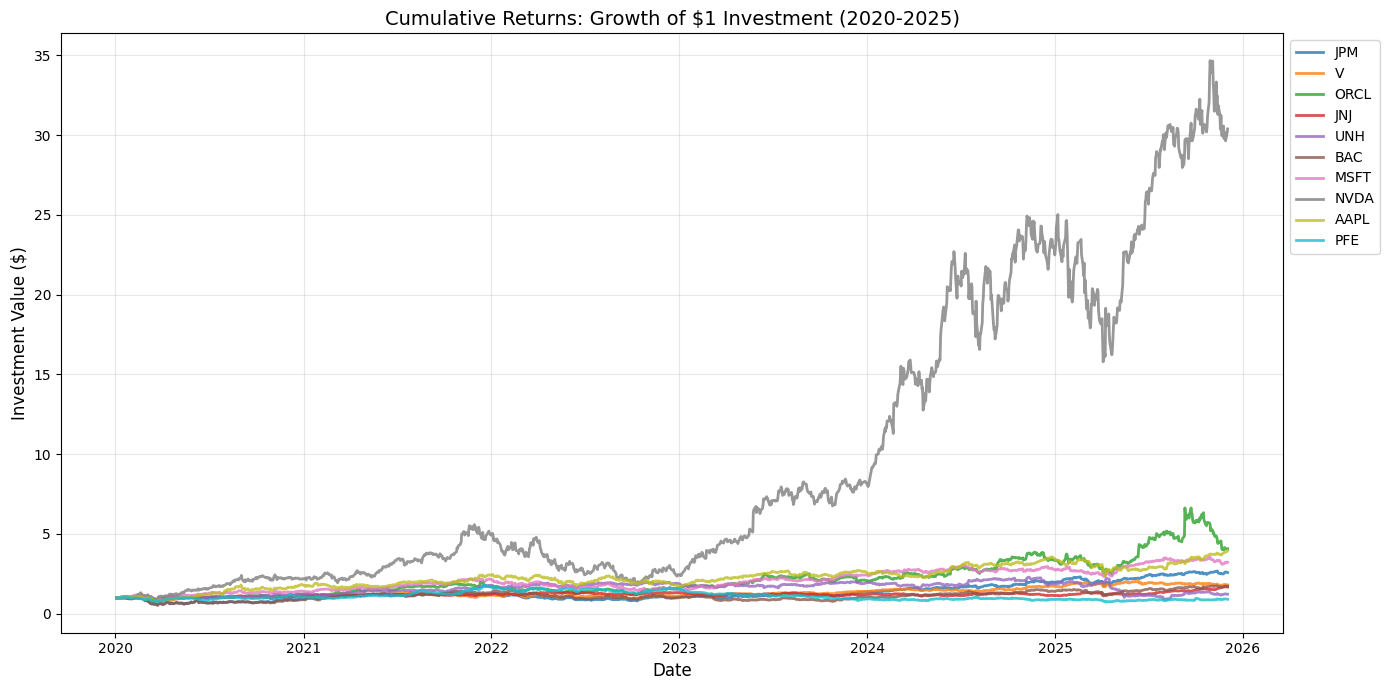

In [8]:
cumulative_returns = (1 + returns).cumprod()

plt.figure(figsize=(14, 7))

colors = plt.get_cmap('tab10', len(cumulative_returns.columns))

for i, c in enumerate(cumulative_returns.columns):
    plt.plot(cumulative_returns.index, cumulative_returns[c], 
             label=c, linewidth=2, alpha=0.8, color=colors(i))

plt.title('Cumulative Returns: Growth of $1 Investment (2020-2025)', fontsize=14)
plt.ylabel('Investment Value ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Cross-Asset Correlations
Correlation matrix of the stocks to understand the relationships between them and diversification prospects.

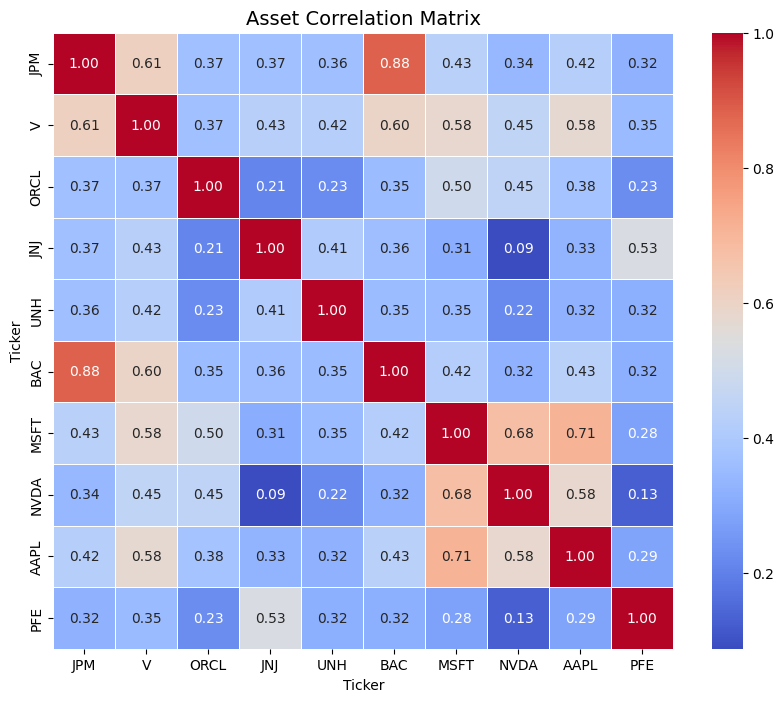

In [9]:
plt.figure(figsize=(10, 8))

corr_matrix = returns.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Asset Correlation Matrix', fontsize=14)
plt.show()

### Markowitz Formulation

For a target annual volatility budget $\sigma_{\text{target}}$, the Markowitz problem is:

$$
\begin{aligned}
& \text{maximize} && \mu^T w \\
& \text{subject to} && w^T \Sigma w \le \sigma_{\text{target}}^2 \\
& && \mathbf{1}^T w = 1 \\
& && w \ge 0
\end{aligned}
$$

This formulation identifies the long-only, fully invested portfolio with the highest expected return for a prescribed volatility budget.

### Risk-Level Definition

The three annual volatility targets are treated as representative investor risk budgets rather than values inferred from the efficient frontier.

- **Low Risk:** `20%`
- **Medium Risk:** `28%`
- **High Risk:** `40%`

These budgets span conservative, balanced, and aggressive positions within the feasible set, while remaining fixed across both optimization methods.


### Method 1: Convex Optimization (ECOS)

The primary convex benchmark solves the target-volatility Markowitz problem directly with `cvxpy` and the `ECOS` solver. Additional solver experiments are retained in the appendix so that the principal comparison remains aligned with the assignment requirements.


#### What ECOS Solves

ECOS is a primal-dual interior-point solver for second-order cone programs (SOCPs). Its objective must be linear, so the quadratic risk constraint $w^\top \Sigma w \le \sigma_{\text{target}}^2$ has to be lifted into a cone.

#### Casting the Markowitz Target-Risk Problem as an SOCP

The target-risk problem is

$$
\max_w \; \mu^\top w
\quad \text{s.t.} \quad
w^\top \Sigma w \le \sigma_{\text{target}}^2, \;
\mathbf{1}^\top w = 1, \;
w \ge 0.
$$

Cholesky-factor $\Sigma = L L^\top$, then

$$
w^\top \Sigma w \le \sigma_{\text{target}}^2
\;\Longleftrightarrow\;
\|L^\top w\|_2 \le \sigma_{\text{target}}
\;\Longleftrightarrow\;
(\sigma_{\text{target}},\, L^\top w) \in \mathcal{Q}^{n+1}.
$$

Negating the objective (ECOS minimizes), the SOCP ECOS actually solves is

$$
\min_w \; -\mu^\top w
\quad \text{s.t.} \quad
\mathbf{1}^\top w = 1, \; w \ge 0, \;
(\sigma_{\text{target}},\, L^\top w) \in \mathcal{Q}^{n+1}.
$$

Cones: one zero cone (budget equality), $n$ nonneg rows (long-only), one second-order cone of dimension $n+1$ (risk cap).

#### Equivalence with the Lagrangian / Penalty Form

Section 5 shows the target-risk form and the penalty form $\max_w \mu^\top w - \gamma w^\top \Sigma w$ trace the same efficient frontier, with the risk-constraint multiplier $\lambda$ playing the role of $\gamma$. At the optimum, the KKT stationarity condition gives

$$
\mu = 2\lambda \Sigma w + \eta \mathbf{1} - \nu, \qquad \nu \ge 0,
$$

which matches the gradient of $\mu^\top w - \gamma w^\top \Sigma w$ when $\gamma = \lambda$. The same optimal $w$ is recovered regardless of which form is solved - only the parametrization differs.

In [10]:
def maximize_return(target_risk, mu, Sigma):
    n = len(mu)
    w_init = cp.Variable(n)

    objective = cp.Maximize(mu.T @ w_init)

    risk_variance = cp.quad_form(w_init, Sigma)
    target_variance = target_risk ** 2

    # long-only, fully invested, with a hard volatility cap
    constraints = [
        cp.sum(w_init) == 1,
        w_init >= 0,
        risk_variance <= target_variance
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.ECOS)

    return w_init.value, prob.value

In [11]:
n = len(mu)
mu_np = mu.values
Sigma_np = Sigma.values
actual_tickers = mu.index

risk_targets = [0.20, 0.28, 0.40]

ecos_results = {}
ecos_weight_series = {}
opt_risks = []
opt_returns = []

print(f"{'Risk':<12} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for target_risk in risk_targets:
    w_opt, ret_opt = maximize_return(target_risk, mu_np, Sigma_np)

    risk_opt = np.sqrt(np.dot(w_opt.T, np.dot(Sigma_np, w_opt)))
    ecos_results[target_risk] = w_opt
    ecos_weight_series[target_risk] = pd.Series(w_opt, index=actual_tickers)
    opt_risks.append(risk_opt)
    opt_returns.append(ret_opt)

    w_series = pd.Series(w_opt, index=actual_tickers).sort_values(ascending=False)
    w_top = w_series[w_series > 0.01]

    top_3_str = ", ".join([f"{t}: {w:.1%}" for t, w in w_top.head(3).items()])
    print(f"{risk_opt:.2%}        | {ret_opt:.2%}        | {top_3_str}")

print()
print("Full ECOS weight table (all tickers):")
ticker_order = ['AAPL', 'MSFT', 'NVDA', 'ORCL', 'JPM', 'V', 'BAC', 'JNJ', 'PFE', 'UNH']
header = f"{'Ticker':<8}" + "".join([f"{'Low':>10}", f"{'Medium':>10}", f"{'High':>10}"])
print(header)
for t in ticker_order:
    row = f"{t:<8}"
    for target_risk in risk_targets:
        w = ecos_weight_series[target_risk].get(t, 0.0)
        row += f"{w:>10.1%}"
    print(row)

Risk         | Exp. Return  | Weights (Top 3)
20.00%        | 25.05%        | JNJ: 62.1%, NVDA: 18.4%, ORCL: 8.1%
28.00%        | 39.74%        | NVDA: 44.1%, JNJ: 44.0%, ORCL: 8.0%
40.00%        | 55.82%        | NVDA: 71.0%, JNJ: 21.3%, ORCL: 7.7%

Full ECOS weight table (all tickers):
Ticker         Low    Medium      High
AAPL          4.6%      0.0%      0.0%
MSFT          0.0%      0.0%      0.0%
NVDA         18.4%     44.1%     71.0%
ORCL          8.1%      8.0%      7.7%
JPM           6.9%      3.9%      0.0%
V             0.0%      0.0%      0.0%
BAC           0.0%      0.0%      0.0%
JNJ          62.1%     44.0%     21.3%
PFE           0.0%      0.0%      0.0%
UNH           0.0%      0.0%      0.0%


### Convex Optimization Results

The ECOS solution matches the risk budgets closely and produces sparse long-only allocations concentrated in the most efficient names within the selected universe.


### Method 2: Monte Carlo Simulation

Random portfolio generation is used as a sampling-based benchmark. The principal submitted comparison uses the **Dirichlet-based sampler** below; alternative sampling designs are retained in the appendix.


#### Dirichlet-Based Sampler

The submitted Monte Carlo benchmark samples long-only portfolios on the simplex with Dirichlet draws and adds a small concentrated tail near the boundary of the feasible set. For each risk budget, the reported Monte Carlo portfolio is the highest-return sampled portfolio that satisfies the volatility limit.


In [12]:
def generate_dirichlet_portfolios(mu_vec, Sigma_mat, n_simulations=100000, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    n_assets = len(mu_vec)
    results = np.zeros((3, n_simulations))
    all_weights = np.zeros((n_simulations, n_assets))

    for i in range(n_simulations):
        if i < 80000:
            weights = rng.dirichlet(np.ones(n_assets))
        else:
            # concentrated 2-asset boundary portfolios
            weights = np.zeros(n_assets)
            indices = rng.choice(n_assets, 2, replace=False)
            w_split = rng.random()
            weights[indices[0]] = w_split
            weights[indices[1]] = 1 - w_split

        all_weights[i] = weights
        port_return = np.dot(weights, mu_vec)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(Sigma_mat, weights)))
        sharpe_ratio = port_return / port_risk

        results[0, i] = port_return
        results[1, i] = port_risk
        results[2, i] = sharpe_ratio

        if (i + 1) % 10000 == 0:
            print(f"  [{i+1:>6d}] ret={port_return:.4f}  risk={port_risk:.4f}  sharpe={sharpe_ratio:.4f}")

    df = pd.DataFrame(results.T, columns=['Return', 'Risk', 'Sharpe'])
    return df, all_weights

In [13]:
df_mc, mc_weights = generate_dirichlet_portfolios(mu_np, Sigma_np)

  [ 10000] ret=0.1491  risk=0.2097  sharpe=0.7109
  [ 20000] ret=0.2556  risk=0.2441  sharpe=1.0471
  [ 30000] ret=0.2151  risk=0.2300  sharpe=0.9351


  [ 40000] ret=0.1714  risk=0.2214  sharpe=0.7744
  [ 50000] ret=0.1830  risk=0.2232  sharpe=0.8199


  [ 60000] ret=0.2355  risk=0.2338  sharpe=1.0073
  [ 70000] ret=0.3063  risk=0.2537  sharpe=1.2074
  [ 80000] ret=0.2374  risk=0.2431  sharpe=0.9766


  [ 90000] ret=0.2035  risk=0.3051  sharpe=0.6672


  [100000] ret=0.2127  risk=0.2923  sharpe=0.7277


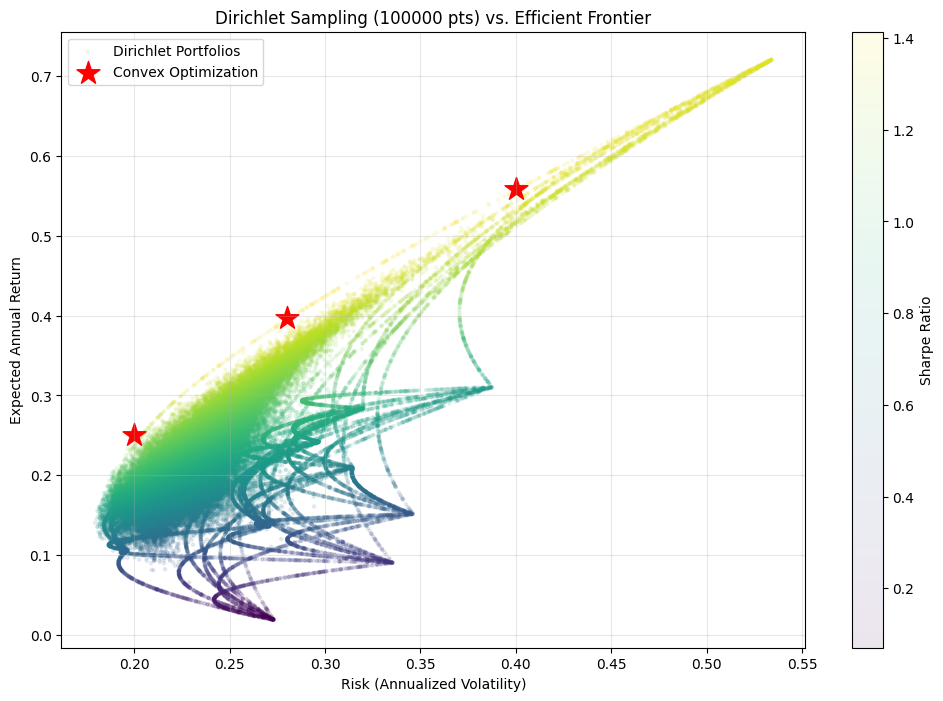

In [14]:
plt.figure(figsize=(12, 8))

plt.scatter(df_mc['Risk'], df_mc['Return'], c=df_mc['Sharpe'], cmap='viridis', alpha=0.1, s=5, label='Dirichlet Portfolios')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(opt_risks, opt_returns, color='red', marker='*', s=300, label='Convex Optimization')

plt.title(f'Dirichlet Sampling (100000 pts) vs. Efficient Frontier')
plt.xlabel('Risk (Annualized Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
risk_targets = [0.20, 0.28, 0.40]

mc_opt_risks = []
mc_opt_returns = []
mc_best_weights = {}

print(f"{'Risk':<12} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for target in risk_targets:
    subset = df_mc[df_mc['Risk'] <= target]

    if not subset.empty:
        best_idx = subset['Return'].idxmax()
        best_port = subset.loc[best_idx]
        best_weights = mc_weights[best_idx]

        mc_opt_risks.append(best_port['Risk'])
        mc_opt_returns.append(best_port['Return'])
        mc_best_weights[target] = pd.Series(best_weights, index=actual_tickers)

        w_series = pd.Series(best_weights, index=actual_tickers).sort_values(ascending=False)
        w_top = w_series[w_series > 0.01]

        top_str = ", ".join([f"{t}: {w:.1%}" for t, w in w_top.head(3).items()])
        print(f"{best_port['Risk']:.2%}        | {best_port['Return']:.2%}        | {top_str}")

print()
print("Full MC weight table:")
ticker_order = ['AAPL', 'MSFT', 'NVDA', 'ORCL', 'JPM', 'V', 'BAC', 'JNJ', 'PFE', 'UNH']
header = f"{'Ticker':<8}" + "".join([f"{'Low':>10}", f"{'Medium':>10}", f"{'High':>10}"])
print(header)
for t in ticker_order:
    row = f"{t:<8}"
    for tgt in risk_targets:
        w = mc_best_weights[tgt].get(t, 0.0)
        row += f"{w:>10.1%}"
    print(row)

Risk         | Exp. Return  | Weights (Top 3)
19.93%        | 23.64%        | JNJ: 52.0%, NVDA: 15.3%, ORCL: 10.5%
27.95%        | 39.40%        | JNJ: 53.2%, NVDA: 46.8%
39.99%        | 55.70%        | NVDA: 73.3%, JNJ: 26.7%

Full MC weight table:
Ticker         Low    Medium      High
AAPL          5.4%      0.0%      0.0%
MSFT          1.8%      0.0%      0.0%
NVDA         15.3%     46.8%     73.3%
ORCL         10.5%      0.0%      0.0%
JPM           0.8%      0.0%      0.0%
V             8.2%      0.0%      0.0%
BAC           1.6%      0.0%      0.0%
JNJ          52.0%     53.2%     26.7%
PFE           0.2%      0.0%      0.0%
UNH           4.3%      0.0%      0.0%


### Monte Carlo Results

The best feasible sampled portfolios lie close to the efficient frontier but are more concentrated than the convex solution. In the saved run, the highest-return feasible portfolio at the low-risk budget includes a small allocation to `ORCL` alongside `JNJ` and `NVDA`; as the risk budget rises the allocation rapidly converges toward a two-name `JNJ`-`NVDA` boundary.

### Direct Comparison: Convex vs Monte Carlo

| Risk Level | ECOS Return | MC Return | Gap | ECOS Risk | MC Risk |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Low (20%) | 25.05% | 23.64% | 1.41 pp | 20.00% | 19.93% |
| Medium (28%) | 39.74% | 39.40% | 0.34 pp | 28.00% | 27.95% |
| High (40%) | 55.82% | 55.70% | 0.12 pp | 40.00% | 39.99% |

The principal comparison uses the **ECOS solution** and the **primary Dirichlet sampler** (cell above). The return gap is largest at the low-risk level where the tighter feasible region makes random search less effective.

### Interpretation

- **Defensive allocations dominate the low-risk budget.** Both methods allocate heavily to `JNJ` at the 20% risk target because it contributes substantial expected return with much lower standalone volatility than `NVDA`.
- **Growth concentration emerges as the risk budget rises.** As the volatility cap increases from 20% to 40%, both methods transfer weight toward `NVDA`, whose higher expected return justifies greater exposure once the risk budget is relaxed.
- **Monte Carlo uses more names at low risk but converges quickly.** At the 20% risk target, the Dirichlet sampler retains small allocations across many names, but at medium and high risk levels both methods collapse to a two-name `JNJ`-`NVDA` boundary.
- **Convex optimization outperforms Monte Carlo at all three risk levels.** ECOS solves the problem exactly while Monte Carlo is sampling-based and therefore does not guarantee the true optimum.
- **The return gap is largest at the low-risk level.** Under tighter constraints, random search has greater difficulty locating the optimal boundary of the feasible region.
- **Sparse weights are economically interpretable.** Several stocks receive zero weight because their estimated return-risk profile is dominated by other names in the selected universe under the imposed long-only constraint.

### Conclusion

For this 10-stock, 3-sector universe, **convex optimization outperforms Monte Carlo at all three risk levels** while matching the target volatility budgets more precisely. Monte Carlo remains useful for intuition and visualization, but it is sampling-based and therefore does not guarantee the exact optimum. The assignment objective is therefore satisfied most cleanly by the convex formulation.


## Appendix

The following sections retain the broader technical exploration from the original notebook. They remain useful for solver intuition and sampling diagnostics, but they do not constitute the core submitted comparison.


### Appendix A: Additional Solver Experiments

This section retains the manual gradient-descent solver and the OSQP-based utility formulation as supporting material.


##### 1. Gradient Descent
Manual implementation using projected gradient descent with Lagrangian dual updates.

**Lagrangian:**

$$\mathcal{L}(w, \lambda) = \mu^T w - \lambda\left(w^T \Sigma w - \sigma_{\text{target}}^2\right)$$

Maximising over $w$ and minimising over $\lambda \ge 0$ (saddle-point formulation). The iterative updates are:

1. **Primal update:** $w^{k+1} = \Pi_{\Delta}\!\left(w^k + \alpha\,\nabla_w \mathcal{L}\right)$ where $\nabla_w \mathcal{L} = \mu - 2\lambda \Sigma w$
2. **Dual update:** $\lambda^{k+1} = \max\!\left(0,\, \lambda^k - \beta\left(w^T \Sigma w - \sigma_{\text{target}}^2\right)\right)$

$\Pi_{\Delta}$ = projection onto the probability simplex (weights sum to 1, non-negative).

In [16]:
def _returns(mu, w):
    return np.dot(mu, w)

def _risk(w, Sigma):
    return np.dot(w.T, np.dot(Sigma, w))

def _gradient_w(w, mu, Sigma, lambd):
    return -mu + lambd * (2 * np.dot(Sigma, w)) # primal grad

def _gradient_lambda(w, Sigma, target_var):
    return _risk(w, Sigma) - target_var # dual grad

def project_simplex(v):
    n = len(v)
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u) - 1
    ind = np.arange(n) + 1
    cond = u - cssv / ind > 0
    rho = ind[cond][-1]
    theta = cssv[cond][-1] / float(rho)
    w = np.maximum(v - theta, 0) # clip negatives
    return w

In [17]:
def solve_markowitz_manual(mu, Sigma, risk_target, lambd = 1.0, max_iter=10000, tol=1e-8):
    n = len(mu)
    w = np.ones(n) / n
    
    lr_w = 0.005
    lr_lambda = 0.5
    target_var = risk_target**2

    for _ in range(max_iter):
        grad_w = _gradient_w(w, mu, Sigma, lambd)
        grad_lambda = _gradient_lambda(w, Sigma, target_var)
        
        w -= lr_w * grad_w # primal step
        w = project_simplex(w)
        
        lambd += lr_lambda * grad_lambda # dual step
        lambd = max(0.0, lambd)

        if np.linalg.norm(lr_w * grad_w) < tol and abs(grad_lambda) < tol:
            break

    return w

In [18]:
n = len(mu)
mu_np = mu.values
Sigma_np = Sigma.values
actual_tickers = mu.index

risk_targets = [0.20, 0.28, 0.40]

results_newton = {}

print(f"{'Risk':<12} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for r in risk_targets:
    w_opt = solve_markowitz_manual(mu_np, Sigma_np, risk_target=r)

    ret_opt = _returns(mu_np, w_opt)
    risk_opt = np.sqrt(_risk(w_opt, Sigma_np))
    results_newton[r] = w_opt

    w_series = pd.Series(w_opt, index=actual_tickers).sort_values(ascending=False)
    w_series = w_series[w_series > 0.01]

    top_3_str = ", ".join([f"{t}: {w:.1%}" for t, w in w_series.head(3).items()])
    print(f"{risk_opt:.2%}        | {ret_opt:.2%}        | {top_3_str}")

Risk         | Exp. Return  | Weights (Top 3)
20.00%        | 25.05%        | JNJ: 62.1%, NVDA: 18.4%, ORCL: 8.1%


28.00%        | 39.74%        | NVDA: 44.1%, JNJ: 44.0%, ORCL: 8.0%


40.00%        | 55.82%        | NVDA: 71.0%, JNJ: 21.3%, ORCL: 7.7%


##### 2. Operator Splitting Quadratic Program (OSQP)
Two-step iterative process using ADMM (Alternating Direction Method of Multipliers):

1. **Unconstrained QP Step:** Minimize quadratic objective ignoring constraints
$$w^{k+1} = \arg\min_w \frac{1}{2}w^T P w + q^T w + \frac{\rho}{2}\|w - z^k + u^k\|_2^2$$

2. **Projection Step:** Project onto feasible set (simplex + non-negativity)
$$z^{k+1} = \Pi_{\mathcal{C}}(w^{k+1} + u^k)$$

Keeps alternating between these two until convergence.

In [19]:
def maximize_utility_osqp(gamma, mu_vec, Sigma_mat):
    n = len(mu_vec)
    w_init = cp.Variable(n)
    
    risk_variance = cp.quad_form(w_init, Sigma_mat)
    objective = cp.Maximize(mu_vec @ w_init - gamma * risk_variance) # utility
    
    constraints = [
        cp.sum(w_init) == 1,
        w_init >= 0
    ]
    
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.OSQP)
    
    return w_init.value

In [20]:
gamma_vals = np.logspace(-1, 2, 100)
osqp_results = []

for g in gamma_vals:
    w_opt = maximize_utility_osqp(g, mu_np, Sigma_np)

    if w_opt is not None:
        ret_val = w_opt @ mu_np
        risk_val = np.sqrt(w_opt.T @ Sigma_np @ w_opt)

        osqp_results.append({
            'gamma': g,
            'weights': w_opt,
            'Return': ret_val,
            'Risk': risk_val
        })

df_osqp = pd.DataFrame(osqp_results)

In [21]:
risk_targets = [0.20, 0.28, 0.40]

print(f"{'Risk Target':<12} | {'Achieved Risk':<15} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for target_risk in risk_targets:
    idx = (df_osqp['Risk'] - target_risk).abs().idxmin()
    best_port = df_osqp.loc[idx]

    w_series = pd.Series(best_port['weights'], index=actual_tickers).sort_values(ascending=False)
    top3 = w_series.head(3)
    w_str = ", ".join([f"{ticker}: {weight:.1%}" for ticker, weight in top3.items()])

    overshoot = " *** OVER BUDGET" if best_port['Risk'] > target_risk + 0.005 else ""
    print(f"{target_risk:.0%}              | {best_port['Risk']:.2%}            | {best_port['Return']:.2%}        | {w_str}{overshoot}")

Risk Target  | Achieved Risk   | Exp. Return  | Weights (Top 3)
20%              | 19.92%            | 24.84%        | JNJ: 62.4%, NVDA: 18.0%, ORCL: 8.1%
28%              | 27.92%            | 39.62%        | JNJ: 44.2%, NVDA: 43.9%, ORCL: 8.0%
40%              | 41.05%            | 57.14%        | NVDA: 73.2%, JNJ: 19.3%, ORCL: 7.6% *** OVER BUDGET


### **Gradient Descent vs. ECOS vs. OSQP**

| Risk Target | **Gradient Descent** | **ECOS** | **OSQP** |
| :--- | :--- | :--- | :--- |
| **20%** | 25.05% | 25.05% | 24.84% |
| **28%** | 39.74% | 39.74% | 39.62% |
| **40%** | 55.82% | 55.82% | 57.14% |

- Gradient Descent and ECOS give the same results because both solve the same constrained maximization problem.
- OSQP minimizes a **utility function** $\mu^T w - \gamma\, w^T \Sigma w$ rather than a hard risk cap, so realized risk need not match the target exactly.
- At the 40% risk target, the closest OSQP solution achieves **41.05% realized volatility**, which exceeds the budget. This is expected: the unconstrained utility sweep does not guarantee a portfolio that lands exactly at the boundary.


### Appendix B: Alternative Monte Carlo Sampling Designs

These sections retain simpler and more concentrated samplers explored during experimentation.


##### 1. Plain Random Sampling
Simple approach - generate random weights uniformly and normalize to sum = 1.
$$w_i = \frac{r_i}{\sum_{j=1}^n r_j}, \quad r_i \sim \text{Uniform}(0,1)$$

In [22]:
def generate_simple_random_portfolios(mu_vec, Sigma_mat, n_simulations=100000, rng=None):
    if rng is None:
        rng = np.random.default_rng(123)
    n_assets = len(mu_vec)
    results = {'Return': [], 'Risk': [], 'Type': []}

    for i in range(n_simulations):
        raw_weights = rng.random(n_assets)
        weights = raw_weights / raw_weights.sum()

        port_return = weights @ mu_vec
        port_risk = np.sqrt(weights.T @ Sigma_mat @ weights)

        results['Return'].append(port_return)
        results['Risk'].append(port_risk)
        results['Type'].append('Plain Random (Uniform)')

        if (i + 1) % 10000 == 0:
            sharpe = port_return / port_risk
            print(f"  [{i+1:>6d}] ret={port_return:.4f}  risk={port_risk:.4f}  sharpe={sharpe:.4f}")

    return pd.DataFrame(results)

  [ 10000] ret=0.2099  risk=0.2255  sharpe=0.9308
  [ 20000] ret=0.2658  risk=0.2290  sharpe=1.1607
  [ 30000] ret=0.2627  risk=0.2523  sharpe=1.0414
  [ 40000] ret=0.2276  risk=0.2339  sharpe=0.9731
  [ 50000] ret=0.1657  risk=0.2216  sharpe=0.7479


  [ 60000] ret=0.2060  risk=0.2310  sharpe=0.8918
  [ 70000] ret=0.2638  risk=0.2306  sharpe=1.1438


  [ 80000] ret=0.2278  risk=0.2184  sharpe=1.0431
  [ 90000] ret=0.2321  risk=0.2300  sharpe=1.0093
  [100000] ret=0.2580  risk=0.2315  sharpe=1.1144


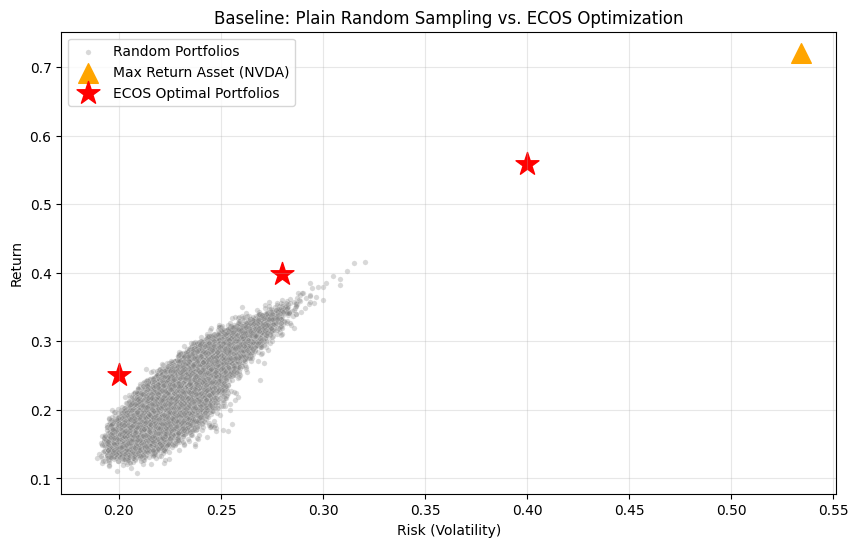

In [23]:
mu_vals = mu_np
Sigma_vals = Sigma_np
df_plain = generate_simple_random_portfolios(mu_np, Sigma_np)

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_plain, x='Risk', y='Return', color='grey', alpha=0.3, s=15, label='Random Portfolios')

max_ret_idx = np.argmax(mu_vals)
plt.scatter(np.sqrt(Sigma_vals[max_ret_idx, max_ret_idx]), mu_vals[max_ret_idx],
            color='orange', marker='^', s=200, label='Max Return Asset (NVDA)')

# Use live ECOS targets - do not overwrite the globals
ecos_risks_plot = opt_risks
ecos_returns_plot = opt_returns
plt.scatter(ecos_risks_plot, ecos_returns_plot, color='red', marker='*', s=300, label='ECOS Optimal Portfolios')

plt.title('Baseline: Plain Random Sampling vs. ECOS Optimization')
plt.xlabel('Risk (Volatility)')
plt.ylabel('Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


##### 2. Uniform Sampling on Simplex
Using uniform sampling + some concentrated portfolios with 2 assets dominating.

In [24]:
def generate_uniform_simplex_portfolios(mu_vec, Sigma_mat, n_simulations=100000, rng=None):
    if rng is None:
        rng = np.random.default_rng(123)
    n_assets = len(mu_vec)
    results = np.zeros((3, n_simulations))

    for i in range(n_simulations):
        if i < 80000:
            u = np.sort(rng.random(n_assets - 1))
            weights = np.diff(np.concatenate([[0], u, [1]]))
        else:
            weights = np.zeros(n_assets)
            indices = rng.choice(n_assets, 2, replace=False)
            w_split = rng.random()
            weights[indices[0]] = w_split
            weights[indices[1]] = 1 - w_split

        port_return = np.dot(weights, mu_vec)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(Sigma_mat, weights)))
        sharpe_ratio = port_return / port_risk

        results[0, i] = port_return
        results[1, i] = port_risk
        results[2, i] = sharpe_ratio

        if (i + 1) % 10000 == 0:
            print(f"  [{i+1:>6d}] ret={port_return:.4f}  risk={port_risk:.4f}  sharpe={sharpe_ratio:.4f}")

    return pd.DataFrame(results.T, columns=['Return', 'Risk', 'Sharpe'])

In [25]:
df_uniform = generate_uniform_simplex_portfolios(mu_np, Sigma_np)

  [ 10000] ret=0.3810  risk=0.2980  sharpe=1.2783
  [ 20000] ret=0.3085  risk=0.2567  sharpe=1.2017
  [ 30000] ret=0.2756  risk=0.2641  sharpe=1.0433
  [ 40000] ret=0.2247  risk=0.2195  sharpe=1.0237
  [ 50000] ret=0.2302  risk=0.2089  sharpe=1.1020


  [ 60000] ret=0.1254  risk=0.2175  sharpe=0.5768
  [ 70000] ret=0.3637  risk=0.2908  sharpe=1.2506
  [ 80000] ret=0.2294  risk=0.2465  sharpe=0.9307
  [ 90000] ret=0.0927  risk=0.1920  sharpe=0.4828
  [100000] ret=0.2391  risk=0.2923  sharpe=0.8180


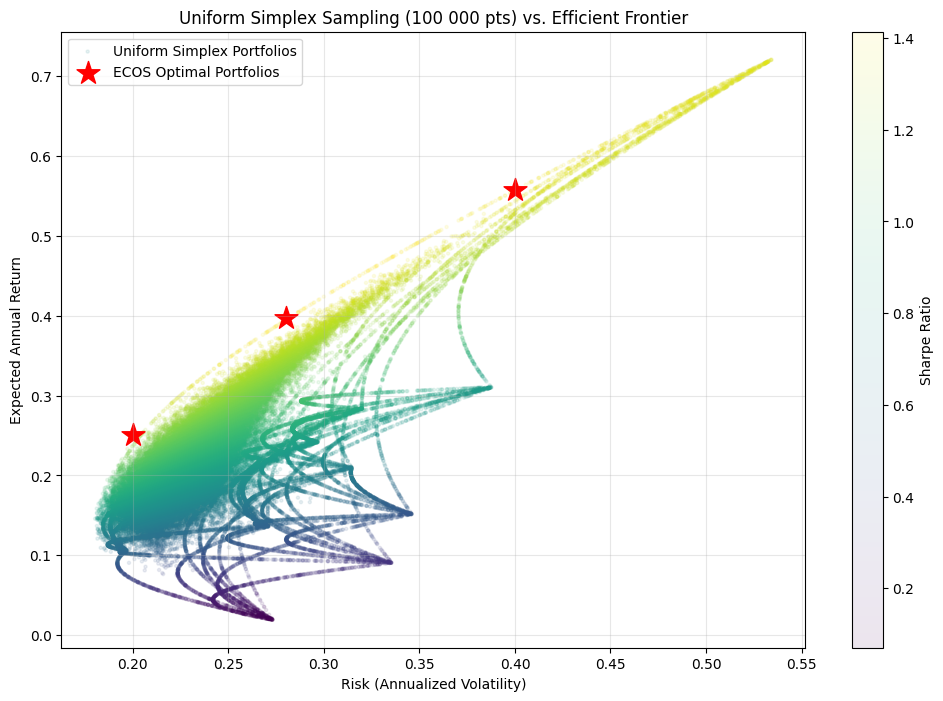

In [26]:
plt.figure(figsize=(12, 8))

plt.scatter(df_uniform['Risk'], df_uniform['Return'], c=df_uniform['Sharpe'], cmap='viridis', alpha=0.1, s=5, label='Uniform Simplex Portfolios')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(opt_risks, opt_returns, color='red', marker='*', s=300, label='ECOS Optimal Portfolios')

plt.title('Uniform Simplex Sampling (100 000 pts) vs. Efficient Frontier')
plt.xlabel('Risk (Annualized Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


##### 3. Dirichlet Sampling (3-Asset Concentrated)
Same Dirichlet approach but with 3 assets dominating in concentrated portfolios.
$$w \sim \text{Dirichlet}(\alpha_1, \alpha_2, ..., \alpha_n), \quad \alpha_i = 1$$
Concentrated portfolios now use 3 assets instead of 2 - exploring more of the frontier edges.

In [27]:
def generate_dirichlet_3asset_portfolios(mu_vec, Sigma_mat, n_simulations=100000, rng=None):
    if rng is None:
        rng = np.random.default_rng(456)
    n_assets = len(mu_vec)
    results = np.zeros((3, n_simulations))
    all_weights = np.zeros((n_simulations, n_assets))

    for i in range(n_simulations):
        if i < 80000:
            weights = rng.dirichlet(np.ones(n_assets))
        else:
            # concentrated 3-asset boundary portfolios
            weights = np.zeros(n_assets)
            indices = rng.choice(n_assets, 3, replace=False)
            w_split = rng.dirichlet(np.ones(3))
            weights[indices[0]] = w_split[0]
            weights[indices[1]] = w_split[1]
            weights[indices[2]] = w_split[2]

        all_weights[i] = weights
        port_return = np.dot(weights, mu_vec)
        port_risk = np.sqrt(np.dot(weights.T, np.dot(Sigma_mat, weights)))
        sharpe_ratio = port_return / port_risk

        results[0, i] = port_return
        results[1, i] = port_risk
        results[2, i] = sharpe_ratio

        if (i + 1) % 10000 == 0:
            print(f"  [{i+1:>6d}] ret={port_return:.4f}  risk={port_risk:.4f}  sharpe={sharpe_ratio:.4f}")

    df = pd.DataFrame(results.T, columns=['Return', 'Risk', 'Sharpe'])
    return df, all_weights

In [28]:
df_mc3, mc_weights3 = generate_dirichlet_3asset_portfolios(mu_np, Sigma_np)

  [ 10000] ret=0.1937  risk=0.2174  sharpe=0.8912
  [ 20000] ret=0.2294  risk=0.2279  sharpe=1.0067
  [ 30000] ret=0.2452  risk=0.2371  sharpe=1.0340
  [ 40000] ret=0.2079  risk=0.2242  sharpe=0.9275
  [ 50000] ret=0.1818  risk=0.2253  sharpe=0.8071


  [ 60000] ret=0.2128  risk=0.2273  sharpe=0.9361
  [ 70000] ret=0.1606  risk=0.1990  sharpe=0.8069
  [ 80000] ret=0.3029  risk=0.2669  sharpe=1.1347
  [ 90000] ret=0.2119  risk=0.2819  sharpe=0.7516


  [100000] ret=0.1750  risk=0.2462  sharpe=0.7107


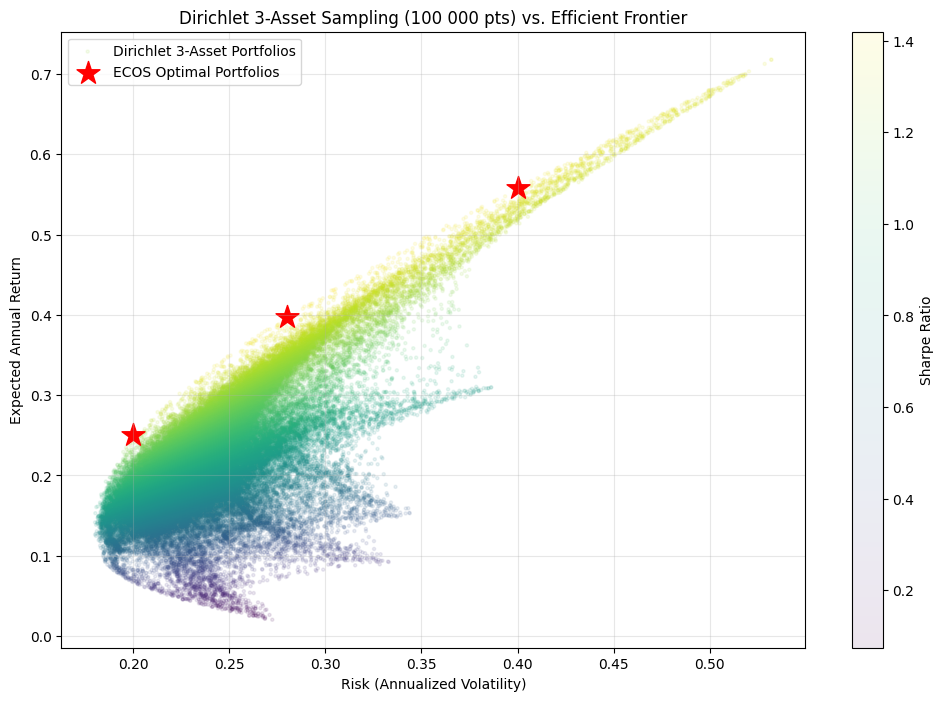

In [29]:
plt.figure(figsize=(12, 8))

plt.scatter(df_mc3['Risk'], df_mc3['Return'], c=df_mc3['Sharpe'], cmap='viridis', alpha=0.1, s=5, label='Dirichlet 3-Asset Portfolios')
plt.colorbar(label='Sharpe Ratio')

plt.scatter(opt_risks, opt_returns, color='red', marker='*', s=300, label='ECOS Optimal Portfolios')

plt.title('Dirichlet 3-Asset Sampling (100 000 pts) vs. Efficient Frontier')
plt.xlabel('Risk (Annualized Volatility)')
plt.ylabel('Expected Annual Return')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()


In [30]:
risk_targets = [0.20, 0.28, 0.40]

print(f"{'Risk':<12} | {'Exp. Return':<12} | {'Weights (Top 3)'}")

for target in risk_targets:
    subset = df_mc3[df_mc3['Risk'] <= target]

    if not subset.empty:
        best_idx = subset['Return'].idxmax()
        best_port = subset.loc[best_idx]
        best_weights = mc_weights3[best_idx]

        w_series = pd.Series(best_weights, index=actual_tickers).sort_values(ascending=False)
        w_top = w_series[w_series > 0.01]

        top_3_str = ", ".join([f"{t}: {w:.1%}" for t, w in w_top.head(3).items()])
        print(f"{best_port['Risk']:.2%}        | {best_port['Return']:.2%}        | {top_3_str}")

Risk         | Exp. Return  | Weights (Top 3)
19.87%        | 23.97%        | JNJ: 69.1%, NVDA: 19.9%, JPM: 11.0%
27.91%        | 39.36%        | JNJ: 52.0%, NVDA: 46.5%, JPM: 1.4%
39.80%        | 55.32%        | NVDA: 70.9%, JNJ: 22.8%, AAPL: 6.3%


### Appendix C: Additional Comparison and Frontier Diagnostics

These diagnostics use the concentrated 3-asset Monte Carlo variant and are therefore retained separately from the principal submitted comparison.


#### Concentrated 3-Asset Variant: Comparison vs ECOS

This appendix comparison uses the more concentrated 3-asset Monte Carlo sampler rather than the principal Dirichlet-based benchmark.


In [31]:
risk_targets = [0.20, 0.28, 0.40]

print(f"{'Risk Target':<12} | {'ECOS Return':<14} | {'MC Return':<14} | {'Gap':<10}")

for target in risk_targets:
    w_ecos, ret_ecos = maximize_return(target, mu_np, Sigma_np)
    risk_ecos = np.sqrt(np.dot(w_ecos.T, np.dot(Sigma_np, w_ecos)))

    subset = df_mc3[df_mc3['Risk'] <= target]
    if not subset.empty:
        best_idx = subset['Return'].idxmax()
        best_port = subset.loc[best_idx]
        ret_mc = best_port['Return']
        risk_mc = best_port['Risk']

        gap = (ret_ecos - ret_mc) * 100
        print(f"{target:.0%}              | {ret_ecos:.2%}             | {ret_mc:.2%}            | {gap:.2f} ")

Risk Target  | ECOS Return    | MC Return      | Gap       
20%              | 25.05%             | 23.97%            | 1.09 
28%              | 39.74%             | 39.36%            | 0.38 
40%              | 55.82%             | 55.32%            | 0.50 


| Risk Target | **ECOS** | **Monte Carlo (Dirichlet 3-Asset)** | **Gap** |
| :--- | :--- | :--- | :--- |
| **20%** | 25.05% | 23.97% | 1.09 pp |
| **28%** | 39.74% | 39.36% | 0.38 pp |
| **40%** | 55.82% | 55.32% | 0.50 pp |

**Note:** This appendix comparison uses the concentrated **3-asset Dirichlet sampler**, not the primary benchmark. The principal submitted comparison (using the standard Dirichlet sampler) is shown in the Direct Comparison section above. Convex optimization outperforms Monte Carlo at all three risk levels; the gap is largest at the low-risk budget where the tighter feasible region makes random search harder.

#### Frontier Visualization with Concentrated Monte Carlo Samples

This plot is retained as an appendix diagnostic because it relies on the concentrated 3-asset Monte Carlo variant rather than the principal submitted sampler.


In [32]:
def find_min_variance_portfolio(Sigma):
    n, w = Sigma.shape[0], cp.Variable(Sigma.shape[0])
    cp.Problem(cp.Minimize(cp.quad_form(w, Sigma)), [cp.sum(w) == 1, w >= 0]).solve(solver=cp.ECOS)
    return w.value

w_gmvp = find_min_variance_portfolio(Sigma_np) # GMVP weights
min_risk, gmvp_return = np.sqrt(w_gmvp.T @ Sigma_np @ w_gmvp), w_gmvp @ mu_np
nvda_idx = list(actual_tickers).index('NVDA')
max_risk, nvda_return = np.sqrt(Sigma_np[nvda_idx, nvda_idx]), mu_np[nvda_idx] # highest risk

print(f"GMVP: {min_risk:.2%} risk, {gmvp_return:.2%} return | NVDA: {max_risk:.2%} risk, {nvda_return:.2%} return")

GMVP: 17.88% risk, 13.11% return | NVDA: 53.43% risk, 72.09% return


In [33]:
N_FRONTIER_POINTS = 100
frontier_risks = np.linspace(min_risk, max_risk, N_FRONTIER_POINTS)
frontier_returns = []
for r in frontier_risks:
    try:
        _, ret = maximize_return(r, mu_np, Sigma_np)
        frontier_returns.append(ret if ret else np.nan)
    except cp.SolverError:
        frontier_returns.append(np.nan)
frontier_returns = np.array(frontier_returns)


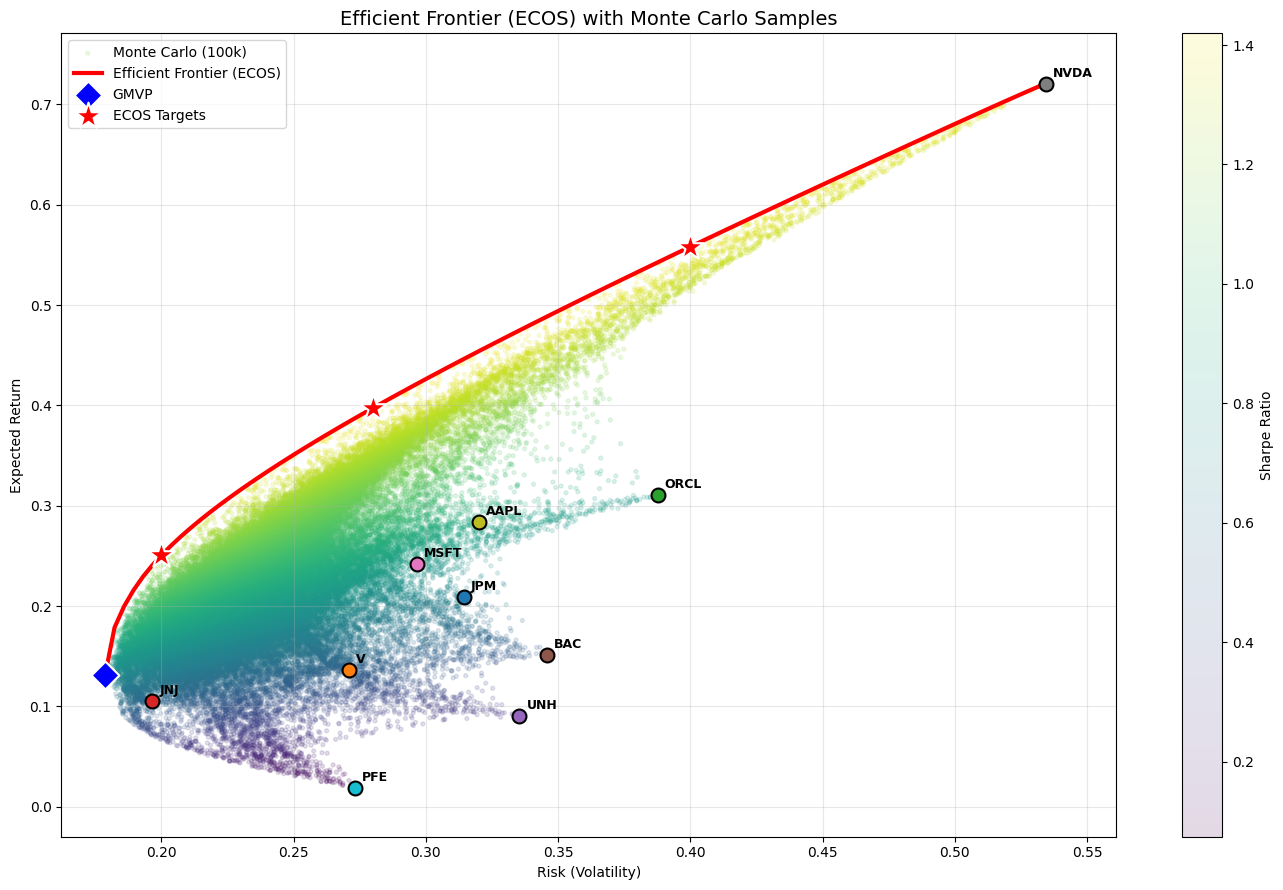

In [34]:
plt.figure(figsize=(14, 9))
plt.scatter(df_mc3['Risk'], df_mc3['Return'], c=df_mc3['Sharpe'], cmap='viridis', alpha=0.15, s=8, label='Monte Carlo (100k)')
plt.colorbar(label='Sharpe Ratio')

valid = ~np.isnan(frontier_returns)
plt.plot(frontier_risks[valid], frontier_returns[valid], 'r-', lw=3, label='Efficient Frontier (ECOS)')
plt.scatter(min_risk, gmvp_return, color='blue', marker='D', s=200, edgecolors='white', lw=1.5, zorder=6, label='GMVP')
plt.scatter(opt_risks, opt_returns, color='red', marker='*', s=400, edgecolors='white', lw=1.5, zorder=5, label='ECOS Targets')

for i, t in enumerate(actual_tickers):
    plt.scatter(np.sqrt(Sigma_np[i, i]), mu_np[i], marker='o', s=100, edgecolors='black', lw=1.5, zorder=4)
    plt.annotate(t, (np.sqrt(Sigma_np[i, i]), mu_np[i]), xytext=(5, 5), textcoords="offset points", fontsize=9, fontweight='bold')

plt.title('Efficient Frontier (ECOS) with Monte Carlo Samples', fontsize=14)
plt.xlabel('Risk (Volatility)')
plt.ylabel('Expected Return')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.xlim(df_mc3['Risk'].min() * 0.9, max(frontier_risks) * 1.05)
plt.ylim(df_mc3['Return'].min() - 0.05, max(frontier_returns[valid]) + 0.05)
plt.tight_layout()
plt.show()
